## Se creará un código



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler



In [53]:
# Cargar archivos de absorción
file_suffix_A = ['AChMN', 'AGo', 'AMi', 'AOx', 'AIlly','AVe','Ally']
dataframes = {}  # Diccionario para almacenar los DataFrames

for file_name in file_suffix_A:
    file_path = f'Data/{file_name}.csv'
    try:
        df = pd.read_csv(file_path)
        dataframes[file_name] = df  # Guardar con el nombre como clave
        print(f"{file_name} CARGADO")
        
    except FileNotFoundError:
        print(f"No se encontró el archivo {file_name}.csv")

# Ahora puedes acceder a cada DataFrame así:
# dataframes['AChMN'], dataframes['AGo'], etc.


AChMN CARGADO
AGo CARGADO
AMi CARGADO
AOx CARGADO
AIlly CARGADO
AVe CARGADO
No se encontró el archivo Ally.csv


In [54]:
# Obtener la longitud de onda correspondiente a las filas limpias
nm_clean = dataframes['AIlly']['nm']
nm_clean.head()

0    200.0
1    200.5
2    201.0
3    201.5
4    202.0
Name: nm, dtype: float64

In [55]:
for name, df in dataframes.items():  
    df.drop(columns='nm', inplace=True, errors='ignore')
    print(f"{name} columnas: {df.columns.tolist()}")
    print(df.head())

AChMN columnas: ['75', '15', '18', '225']
    75   15   18  225
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0
AGo columnas: ['75', '15', '18', '225']
    75   15   18  225
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0
AMi columnas: ['75', '15', '18', '225']
    75   15   18  225
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0
AOx columnas: ['75', '15', '18', '225']
    75   15   18  225
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0
AIlly columnas: ['75', '15', '18', '225']
    75   15   18  225
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0
AVe columnas: ['75', '15', '18', '225']
      75     15   18  225
0  1.258  1.278  0.0  0.0
1  1.259  1.302  0.0  0.0
2  1.252  1.249  0

In [56]:
# Preparar los datos
# ------------------------------
# X: absorbancias de los 4 cafés
X = pd.concat([dataframes['AChMN'], dataframes['AGo'], dataframes['AMi'], dataframes['AOx']], axis=1)
X.columns = ['AChMN75','AChMN15','AChMN18','AChMN225',
             'AGo75','AGo15','AGo18','AGo225',
             'AMi75','AMi15','AMi18','AMi225',
             'AOx75','AOx15','AOx18','AOx225']
X.head(100)

,AChMN75,AChMN15,AChMN18,AChMN225,AGo75,AGo15,AGo18,AGo225,AMi75,AMi15,AMi18,AMi225,AOx75,AOx15,AOx18,AOx225
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.335,0.702,0.463,0.792,0.290,0.728,0.625,0.607,0.237,0.597,0.450,0.572,0.244,0.866,0.809,0.987
96,0.334,0.700,0.462,0.792,0.290,0.728,0.625,0.607,0.236,0.597,0.449,0.570,0.243,0.862,0.806,0.983
97,0.333,0.698,0.461,0.793,0.291,0.728,0.626,0.608,0.235,0.598,0.448,0.568,0.242,0.858,0.803,0.980
98,0.333,0.696,0.461,0.793,0.292,0.728,0.627,0.610,0.234,0.599,0.447,0.566,0.241,0.855,0.800,0.976


In [57]:
dataframes['AIlly'].head()


,75,15,18,225
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


In [58]:
# y: absorbancia de AIlly15
y = dataframes['AIlly']['15'].rename('AIlly15')  # renombrar para evitar KeyError
y



0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
416    0.0
417    0.0
418    0.0
419    0.0
420    0.0
Name: AIlly15, Length: 421, dtype: float64

In [59]:
# ------------------------------
# Manejo de NaN
# ------------------------------
# Concatenar X y y para eliminar filas con NaN
data = pd.concat([X, y], axis=1)
#data_clean = data.dropna()  # elimina cualquier fila con NaN

X_clean = data[['AChMN75','AChMN15','AChMN18','AChMN225',
             'AGo75','AGo15','AGo18','AGo225',
             'AMi75','AMi15','AMi18','AMi225',
             'AOx75','AOx15','AOx18','AOx225']]
y_clean = data['AIlly15']




In [60]:

data.isnull().sum()  # Verificar si hay NaN restantes


AChMN75     0
AChMN15     0
AChMN18     0
AChMN225    0
AGo75       0
AGo15       0
AGo18       0
AGo225      0
AMi75       0
AMi15       0
AMi18       0
AMi225      0
AOx75       0
AOx15       0
AOx18       0
AOx225      0
AIlly15     0
dtype: int64

In [64]:
data.info()  # Verificar tipos de datos y NaN restantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AChMN75   421 non-null    float64
 1   AChMN15   421 non-null    float64
 2   AChMN18   421 non-null    float64
 3   AChMN225  421 non-null    float64
 4   AGo75     421 non-null    float64
 5   AGo15     421 non-null    float64
 6   AGo18     421 non-null    float64
 7   AGo225    421 non-null    float64
 8   AMi75     421 non-null    float64
 9   AMi15     421 non-null    float64
 10  AMi18     421 non-null    float64
 11  AMi225    421 non-null    float64
 12  AOx75     421 non-null    float64
 13  AOx15     421 non-null    float64
 14  AOx18     421 non-null    float64
 15  AOx225    421 non-null    float64
 16  AIlly15   421 non-null    float64
dtypes: float64(17)
memory usage: 56.0 KB


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size = 0.20, random_state = 42)

In [61]:

# Escalar datos (recomendado para Random Forest y MLP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lizoro/Proyects/cafelab_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

ValueError: x and y must have same first dimension, but have shapes (421,) and (85,)

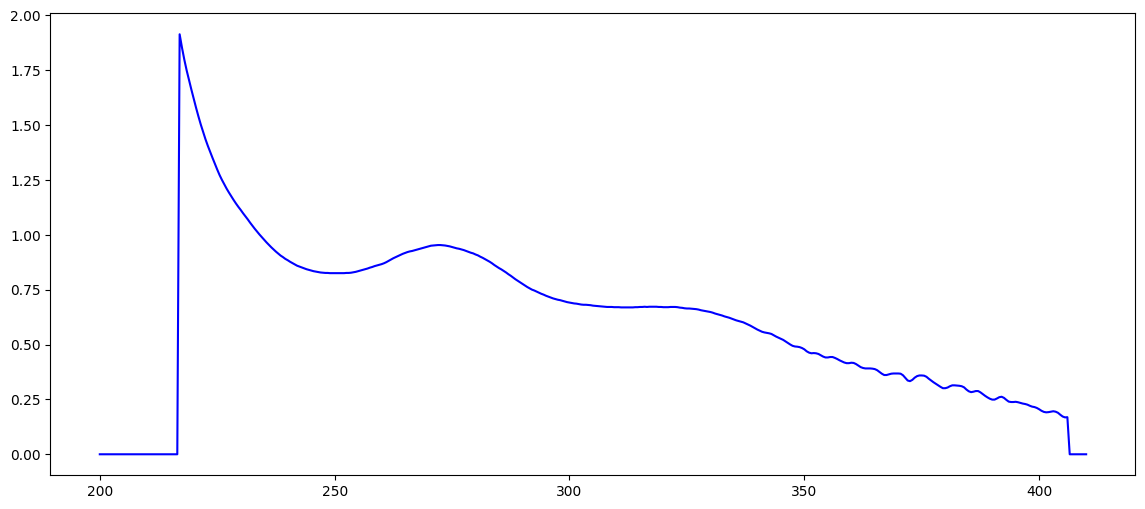

In [66]:

# ------------------------------
# 1️⃣ Linear Regression
# ------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# ------------------------------
# 2️⃣ Random Forest
# ------------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# ------------------------------
# 3️⃣ Red Neuronal (MLP)
# ------------------------------
mlp_model = MLPRegressor(hidden_layer_sizes=(50,50), activation='relu', max_iter=2000, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# ------------------------------
# Graficar resultados
# ------------------------------
plt.figure(figsize=(14,6))
plt.plot(nm_clean, y_clean, label='AIlly15 real', color='blue')
plt.plot(nm_clean, y_pred_lr, label='Predicción LinearRegression', linestyle='--', color='red')
plt.plot(nm_clean, y_pred_rf, label='Predicción Random Forest', linestyle='--', color='green')
plt.plot(nm_clean, y_pred_mlp, label='Predicción MLP', linestyle='--', color='orange')
plt.xlabel('Longitud de Onda (nm)')
plt.ylabel('Absorbancia')
plt.title('Predicción de AIlly15 a partir de otros cafés')
plt.legend()
plt.show()

> contribución

1.	Para Linear Regression: calcula los porcentajes relativos de los coeficientes.
2.	Para Random Forest: muestra la importancia de cada variable en la predicción.
3.	Para MLP: usa permutation importance, que mide cuánto afecta cada variable a la predicción.

Esto te permite ver qué cafés contribuyen más a predecir la curva de AIlly15 según cada modelo.

In [ ]:
from sklearn.inspection import permutation_importance

print("=== Contribución de cada café para predecir AIlly15 ===\n")

# 1️⃣ Linear Regression
coefs = lr_model.coef_
coefs_percent = 100 * coefs / coefs.sum()
print("Linear Regression:")
for cafe, perc in zip(X_clean.columns, coefs_percent):
    print(f"  {cafe}: {perc:.2f}%")
print("\n")

# 2️⃣ Random Forest
importances = rf_model.feature_importances_
importances_percent = 100 * importances / importances.sum()
print("Random Forest:")
for cafe, perc in zip(X_clean.columns, importances_percent):
    print(f"  {cafe}: {perc:.2f}%")
print("\n")

# 3️⃣ MLP (Permutation Importance)
result = permutation_importance(mlp_model, X_scaled, y_clean, n_repeats=30, random_state=42)
perm_importances = result.importances_mean
perm_percent = 100 * perm_importances / perm_importances.sum()
print("MLP Regressor (permutation importance):")
for cafe, perc in zip(X_clean.columns, perm_percent):
    print(f"  {cafe}: {perc:.2f}%")